# 道集划分可视化（CSG / CRG）

与 `generate_dataset_bak.py` 中 `gather()` 的数据组织一致：

- **CSG**：键 `(shot_line, shot_stake)`，道集内 trace 按 `(recv_line, recv_stake)` 排序。
- **CRG**：键 `(recv_line, recv_stake)`，道集内按 `(shot_line, shot_stake)` 排序。

使用前请确认下方 `BASE_DIR` / `GROUP_NAME` / `H5_NAME` 与实际数据一致。

**注意**：`gather(info_f, mode)` 的第一个参数必须是 **已打开的 h5py Group**（例如 `File(path)["1551"]`），不要传入 HDF5 文件路径字符串。

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from h5py import File

# 与本 notebook 同目录的 generate_dataset_bak
REG_TOOL = "/NAS/czt/mount/seis_flow_data12V2/reg_tool"
if REG_TOOL not in sys.path:
    sys.path.insert(0, REG_TOOL)

from core import gather, _read_array

In [ ]:
# 与 generate_dataset_bak.py __main__ 中路径一致，可按需修改
BASE_DIR = "/NAS/czt/mount/seis_flow_data12V2/h5/dongfang/"
H5_NAME = "reg5dbin_label1031_binning.h5"  # 或 raw5d_data1104.h5 / reg5dbin_label1031.h5
GROUP_NAME = "1551"

H5_PATH = os.path.join(BASE_DIR, H5_NAME)
assert os.path.isfile(H5_PATH), f"未找到文件: {H5_PATH}"

In [ ]:
with File(H5_PATH, "r") as hf:
    info_f = hf[GROUP_NAME]
    print("datasets:", list(info_f.keys()))
    mode = "crg"  # 改为 "crg" 查看共检波点道集
    gathers = gather(info_f, mode)

n_gathers = len(gathers)
sizes = np.array([len(v) for v in gathers.values()], dtype=np.int64)
print(f"mode={mode}, 道集数={n_gathers}, 总道数={sizes.sum()}, 每道集道数: min={sizes.min()} max={sizes.max()} median={np.median(sizes):.0f}")

## 1. 道集规模（直方图）

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=min(80, max(10, n_gathers // 50)), color="steelblue", edgecolor="white")
ax.set_xlabel("traces per gather")
ax.set_ylabel("count")
ax.set_title(f"Gather size histogram ({mode.upper()})")
plt.tight_layout()
plt.show()

## 2. 全数据：按道集着色（rx–ry 或 sx–sy）

- CSG：用接收点坐标 `(rx, ry)` 展示同一炮下检波点分布。
- CRG：用炮点坐标 `(sx, sy)` 展示同一检波点下炮点分布。

道集数量很大时只抽样部分道集上色，其余灰色。

In [ ]:
with File(H5_PATH, "r") as hf:
    g = hf[GROUP_NAME]
    rx = _read_array(g, "rx").astype(np.float64)
    ry = _read_array(g, "ry").astype(np.float64)
    sx = _read_array(g, "sx").astype(np.float64)
    sy = _read_array(g, "sy").astype(np.float64)
    n = len(rx)

keys = list(gathers.keys())
rng = np.random.default_rng(0)
n_color = min(400, n_gathers)
picked = set(rng.choice(len(keys), size=n_color, replace=False))
gather_id = np.full(n, -1, dtype=np.int32)
for gi, k in enumerate(keys):
    if gi not in picked:
        continue
    for ti in gathers[k]:
        gather_id[int(ti)] = gi

if mode == "csg":
    x, y = rx, ry
    xlab, ylab = "rx", "ry"
else:
    x, y = sx, sy
    xlab, ylab = "sx", "sy"

fig, ax = plt.subplots(figsize=(7, 6))
mask_bg = gather_id < 0
ax.scatter(x[mask_bg], y[mask_bg], s=1, c="lightgray", alpha=0.35, label="other gathers")
sc = ax.scatter(x[~mask_bg], y[~mask_bg], s=2, c=gather_id[~mask_bg], cmap="tab20", alpha=0.85)
plt.colorbar(sc, ax=ax, label="gather id (sampled)")
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
ax.set_title(f"Traces colored by {mode.upper()} gather (subset)")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

## 3. 典型道集：子图展示若干道集内空间分布

- **CSG**：每个子图为一炮，横纵为 `recv_line`–`recv_stake` 或 `rx`–`ry`。
- **CRG**：每个子图为一检波点，横纵为 `shot_line`–`shot_stake` 或 `sx`–`sy`。

In [ ]:
with File(H5_PATH, "r") as hf:
    g = hf[GROUP_NAME]
    shot_line = _read_array(g, "shot_line").astype(np.float64)
    shot_stake = _read_array(g, "shot_stake").astype(np.float64)
    recv_line = _read_array(g, "recv_line").astype(np.float64)
    recv_stake = _read_array(g, "recv_stake").astype(np.float64)

n_show = min(6, n_gathers)
# 不能对 keys 直接 choice：numpy 会把元组变成 ndarray，导致 unhashable，无法作为 gathers 的键
if n_gathers <= 6:
    show_keys = list(keys[:n_show])
else:
    sel = rng.choice(len(keys), size=n_show, replace=False)
    show_keys = [keys[i] for i in sel]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.ravel()
for ax, k in zip(axes, show_keys):
    idx = np.asarray(gathers[k], dtype=np.intp)
    if mode == "csg":
        ax.scatter(recv_line[idx], recv_stake[idx], s=8, c=np.arange(len(idx)), cmap="viridis")
        ax.set_xlabel("recv_line")
        ax.set_ylabel("recv_stake")
        ax.set_title(f"CSG key={k}")
    else:
        ax.scatter(shot_line[idx], shot_stake[idx], s=8, c=np.arange(len(idx)), cmap="viridis")
        ax.set_xlabel("shot_line")
        ax.set_ylabel("shot_stake")
        ax.set_title(f"CRG key={k}")
plt.suptitle("Example gathers (line/stake grid)")
plt.tight_layout()
plt.show()

## 4.（可选）单道集地震数据：`imshow`

任取 **第一个道集** `keys[0]`。在编号满足 `L,L+1,L+2` 的「连续三条线」有多组候选时 **随机取一组**（`triplet_rng` 种子可调）。

- **CSG**：三条 **接收线** `recv_line`，线内按 `recv_stake` 排序后横向拼接。
- **CRG**：道集内 `recv_line` 不变，与 CSG 对称——三条 **炮线** `shot_line`，线内按 `shot_stake` 排序。

显示方式与 `read_dongfang_label.ipynb` 一致：`data.T`、`seismic`、`±2*std`。

未找到编号连续 +1 的三条线，改用前三条唯一线: [105100, 105200, 105300]
CRG：随机连续三条炮线 shot_line=[105100, 105200, 105300]


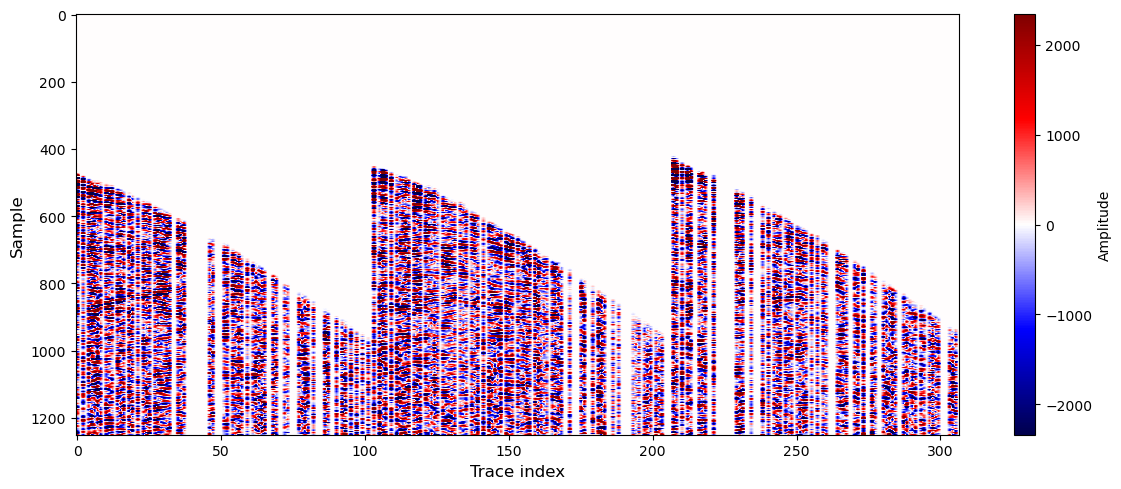

In [14]:
def _random_triplet_consecutive_plus1(unique_lines, rng):
    """在排序后的唯一线号中，找出所有满足 L,L+1,L+2 的三元组，随机选一组；若无则退回前三条唯一线。"""
    u = np.asarray(unique_lines, dtype=np.int64)
    if u.size < 3:
        return list(u)
    triplets = []
    for i in range(u.size - 2):
        a, b, c = int(u[i]), int(u[i + 1]), int(u[i + 2])
        if b == a + 1 and c == a + 2:
            triplets.append([a, b, c])
    if triplets:
        return list(rng.choice(triplets))
    print(f"未找到编号连续 +1 的三条线，改用前三条唯一线: {list(u[:3])}")
    return list(u[:3])


with File(H5_PATH, "r") as hf:
    g = hf[GROUP_NAME]
    data = _read_array(g, "data")
    recv_line_all = _read_array(g, "recv_line").astype(np.int64)
    recv_stake_all = _read_array(g, "recv_stake").astype(np.int64)
    shot_line_all = _read_array(g, "shot_line").astype(np.int64)
    shot_stake_all = _read_array(g, "shot_stake").astype(np.int64)

k0 = keys[0]
idx0 = np.asarray(gathers[k0], dtype=np.intp)
triplet_rng = np.random.default_rng(42)  # 改种子可换一组「连续三条线」

if len(idx0) < 1:
    print("该道集无道，跳过")
elif data.ndim != 2:
    print("data 不是二维 (N, nt)，跳过显示")
else:
    if mode == "crg":
        # CRG：道集内 recv_line 不变，与 CSG 对称——用炮线 shot_line 抽随机连续三条
        shot_line_in = shot_line_all[idx0]
        unique_lines = np.unique(shot_line_in)
        selected_lines = _random_triplet_consecutive_plus1(unique_lines, triplet_rng)
        if len(unique_lines) < 3:
            print(f"不同炮线仅 {len(unique_lines)} 条，全部显示: {selected_lines}")
        else:
            print(f"CRG：随机连续三条炮线 shot_line={selected_lines}")
        blocks = []
        for line_val in selected_lines:
            mask = shot_line_in == line_val
            sub_idx = idx0[mask]
            order = np.argsort(shot_stake_all[sub_idx])
            sub_idx = sub_idx[order]
            blocks.append(data[sub_idx])
        w = np.vstack(blocks) if blocks else data[idx0]
        subtitle = f"随机连续 {len(selected_lines)} 条炮线"
        line_info = f"，shot_line={selected_lines}"
    else:
        # CSG：随机连续三条接收线 recv_line（候选多条时随机取一组 L,L+1,L+2）
        recv_line_in = recv_line_all[idx0]
        unique_lines = np.unique(recv_line_in)
        selected_lines = _random_triplet_consecutive_plus1(unique_lines, triplet_rng)
        if len(unique_lines) < 3:
            print(f"不同接收线仅 {len(unique_lines)} 条，全部显示: {selected_lines}")
        else:
            print(f"CSG：随机连续三条接收线 recv_line={selected_lines}")
        blocks = []
        for line_val in selected_lines:
            mask = recv_line_in == line_val
            sub_idx = idx0[mask]
            order = np.argsort(recv_stake_all[sub_idx])
            sub_idx = sub_idx[order]
            blocks.append(data[sub_idx])
        w = np.vstack(blocks) if blocks else data[idx0]
        subtitle = f"随机连续 {len(selected_lines)} 条接收线"
        line_info = f"，recv_line={selected_lines}"

    std = float(np.std(w)) if np.std(w) > 0 else 1.0
    vmax = 2.0 * std
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(
        w.T,
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        origin="upper",
        interpolation="bilinear",
    )
    ax.set_xlabel("Trace index", fontsize=12)
    ax.set_ylabel("Sample", fontsize=12)
    plt.colorbar(im, ax=ax, label="Amplitude")
    plt.tight_layout()
    plt.show()